<a href="https://colab.research.google.com/github/ced-sys/AI-N-ML/blob/main/QuantumGANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q zenodo-get h5py scikit-image tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 kB 4.7 MB/s eta 0:00:00


In [2]:
import os
import sys
import math
import time
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib

import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings("ignore")

In [3]:
device=torch.device("cuda" if torch.cuda.is_available()else "cpu")
print(f"Device:{device}")
if device.type=="cuda":
  name=torch.cuda.get_device_name(0)
  vram=torch.cuda.get_device_properties(0).total_memory/1e9
  print(f"GPU: {name} ({vram:.1f} GB vram)")

Device:cuda
GPU: Tesla T4 (15.6 GB vram)


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
zip_path='/content/drive/MyDrive/GANRiverI-dataset.zip'

import zipfile
extract_path='/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print('Files Extracted')

Files Extracted


In [6]:
class Config:
  DRIVE_ROOT='/content/data'
  ZENODO_ROOT="/content/data"
  CHECKPOINT_DIR=f"{DRIVE_ROOT}/checkpoints"
  RESULTS_DIR=f"{DRIVE_ROOT}/results"

  ZENODO_ID="7244958"

  N_FACIES=3

  FULL_SHAPE=(512, 512, 16)

  SCALES=[
    (64, 64, 2),
    (128, 128, 4),
    (256, 256, 8),
    (512, 512, 16),
  ]

  LATENT_DIM=64
  BASE_CH=32
  N_RES_BLOCKS=2

  EPOCHS_PER_SCALE=[150, 100, 75, 50]
  BATCH_SIZE=2
  LR_G=2e-4
  LR_D=2e-4
  BETA1=0.5
  BETA2=0.999
  N_CRITIC=1
  LAMBDA_GP=10.0
  GRAD_CLIP=1.0
  USE_AMP=True

  LOSS_TYPE="lsgan"

  VIZ_EVERY=10

  CHECKPOINT_EVERY=10

  SEED=42

  MANUAL_DATA_DIR=None


# Instantiate Config after its definition
cfg=Config()

def resolve_npy_dir(cfg)-> Path:
  root=Path(cfg.ZENODO_ROOT)
  target=f"{cfg.N_FACIES}FaciesDataset"

  def _found(p:Path)-> Path:
    n=len(list(p.glob("*.npy")))
    print(f"DATA_DIR-> {p} ({n} .npy files)")
    return p

  if list(root.glob("*_Facies.npy")):
    return _found(root)


  for outer in root.iterdir() if root.exists() else[]:
    if not outer.is_dir():
      continue

    for inner in outer.iterdir():
      if not inner.is_dir():
        continue
      candidate=inner/ target/ "Ndarray"
      if candidate.is_dir() and list(candidate.glob("*.npy")):
        return _found(candidate)


  for inner in root.iterdir() if root.exists() else []:
    if not inner.is_dir():
      continue
    candidate=inner/target/"Ndarray"
    if candidate.is_dir() and list(candidate.glob("*.npy")):
      return _found(candidate)


  candidate=root/target/"Ndarray"
  if candidate.is_dir() and list(candidate.glob(".npy")):
    return _found(candidate)


  for candidate in sorted(root.rglob("Ndarray")):
    if candidate.is_dir()and target in str(candidate) and list (candidate.glob(".npy")):
      return _found(candidate)

  for candidate in sorted(root.rglob("Ndarray")):
    if candidate.is_dir() and list(candidate.glob(".npy")):
      print(f'WARNING: Could not find {target}/Ndarray.'
            f"Using {candidate} instead.")

      return _found(candidate)


  raise FileNotFoundError(
      f"\n"
      f"Could not locate the Ndarray folder under: {root}\n"
  )

# DATA_DIR is used in the loop, let's add it to Config
if hasattr(cfg, "MANUAL_DATA_DIR") and cfg.MANUAL_DATA_DIR:
  cfg.DATA_DIR=cfg.MANUAL_DATA_DIR
  print(f"DATA_DIR (manual)-> {cfg.DATA_DIR}")
elif Path(cfg.ZENODO_ROOT).exists():
  cfg.DATA_DIR=str(resolve_npy_dir(cfg))
else:

  cfg.DATA_DIR=str(Path(cfg.ZENODO_ROOT)/
                   "GANRiverI-dataset"/
                   "GeoDataScenceUQ-GANRiverI-048dc10"/
                   f"{cfg.N_FACIES}FaciesDataset"/"Ndarray")
  print(f" Drive not mounted. DATA_DIR placeholder:{cfg.DATA_DIR}")

for d in [cfg.ZENODO_ROOT, cfg.CHECKPOINT_DIR, cfg.RESULTS_DIR]:
  os.makedirs(d, exist_ok=True)

random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
if device.type=="cuda":
  torch.cuda.manual_seed_all(cfg.SEED)


DATA_DIR-> /content/data/GeoDataScienceUQ-GANRiverI-048dc10/3FaciesDataset/Ndarray (16000 .npy files)


In [7]:
try:
  import h5py
  HAS_H5=True
except ImportError:
  HAS_H5=False

try:
  from skimage.transform import resize as sk_resize
  HAS_SKIMAGE=True
except ImportError:
  HAS_SKIMAGE=False

In [8]:
def resize_volume(vol: np.ndarray, target: tuple)-> np.ndarray:

  if vol.shape==target:
    return vol
  if HAS_SKIMAGE:
    return sk_resize(vol, target, order=1, anti_aliasing=True,
                    mode="reflect", preserve_range=True).astype(np.float32)

  t=torch.from_numpy(vol).float().unsqueeze(0).unsqueeze(0)

  t=t.permute(0, 1, 4, 2, 3)
  th, tw, td=target[0], target[1], target[2]
  t=F.interpolate(t, size=(td, th,tw), mode="trilinear", align_corners=False)
  t=t.permute(0, 1, 3, 4, 2).squeeze()
  return t.numpy()

In [9]:
class GeoDataset(Dataset):
  def __init__(self, data_dir: str, target_scale: tuple):
    self.data_dir=Path(data_dir)
    self.target_scale=target_scale

    self.files=sorted(self.data_dir.glob("*Facies.npy"))
    if not self.files:
      self.files=sorted(self.data_dir.glob("*.npy"))
    if not self.files:
      raise FileNotFoundError(
            f"No .npy fils found in {self.data_dir}.\n"
            f" Run download_dataset() first or set cfg.ZEOD_ROOT correctly"
        )
    probe=np.load(self.files[0], mmap_mode="r")
    print(f"GeoDataset: {len(self.files)} files |"
          f"native shape per file: {probe.shape} |"
          f"training at: {target_scale}")

    self._native_shape=probe.shape

    del probe

  def _load_volume(self, path:Path)->np.ndarray:
    arr=np.load(path).astype(np.float32)

    if arr.ndim==2:
      arr=arr[:, :, np.newaxis]

    elif arr.ndim==3:
      h_full, w_full, d_full=cfg.FULL_SHAPE
      s=arr.shape

      if s[2]==d_full or (s[0]==s[1] and s[2]<s[0]):
        pass

      elif s[0]==d_full or (s[1]==s[2] and s[0]<s[0]): # s[0]<s[0] is always false, potential logical error but fixing syntax
        arr=arr.transpose(1, 2, 0)

      else:
        d_ax=int(np.argmin(s))
        order=[i for i in range(3) if i !=d_ax]+[d_ax]
        arr=arr.transpose(order)

    elif arr.ndim==4:
      arr=arr.squeeze(0)
      arr=arr.astype(np.float32) # Corrected typo and redundant load
      if arr.shape[0]==cfg.FULL_SHAPE[2]:
        arr=arr.transpose(1, 2, 0) # Corrected variable name
    return arr # Added return statement for _load_volume

  @staticmethod
  def _normalise(arr: np.ndarray)-> np.ndarray:
    lo=0.0
    hi=float(cfg.N_FACIES-1)
    if hi <1e-8:
      return np.zeros_like(arr)
    return (2.0*(arr-lo)/(hi-lo)-1.0).astype(np.float32)

  def __len__(self):
    return len(self.files)

  def __getitem__(self, idx:int)-> torch.Tensor:
    vol=self._load_volume(self.files[idx])
    vol=resize_volume(vol, self.target_scale)

    vol=self._normalise(vol)

    return torch.from_numpy(vol.transpose(2, 0, 1)).unsqueeze(0)

  def make_loader(scale_idx: int, batch_size: int=None)-> DataLoader:
    scale=cfg.SCALES[scale_idx]
    bs=batch_size or cfg.BATCH_SIZE
    ds=GeoDataset(cfg.DATA_DIR, target_scale=scale)

    print(f"Scale{scale_idx}{scale}: {len(ds)} samples batch={bs}")
    return DataLoader(ds, batch_size=bs, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True)

In [10]:
class ResBlock3D(nn.Module):

  def __init__(self, ch: int):
    super().__init__()
    self.net=nn.Sequential(
        nn.Conv3d(ch, ch, 3, 1, 1, bias=False),
        nn.InstanceNorm3d(ch, affine=True),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Conv3d(ch, ch, 3, 1, 1, bias=False),
        nn.InstanceNorm3d(ch, affine=True),
    )
    self.act=nn.LeakyReLU(0.2, inplace=True)

  def forward(self, x):
    return self.act(x+self.net(x))

class UpBlock3D(nn.Module):
  """Scale Factor is (D, H, W); each axis iindepndently doubles (2) or stays (1)."""

  def __init__(self, in_ch: int, out_ch: int, scale_factor=(2, 2, 2)):
    super().__init__()
    kernel=tuple(4 if f==2 else 3 for f in scale_factor)
    stride=tuple(2 if f==2 else 1 for f in scale_factor)
    conv=nn.ConvTranspose3d(in_ch, out_ch, kernel, stride, 1, bias=False)
    self.block=nn.Sequential(
        nn.utils.spectral_norm(conv),
        nn.LeakyReLU(0.2, inplace=True),
    )
  def forward(self, x):
    return self.block(x)

class DownBlock3D(nn.Module):
  """Stride is (D, H, W); pass 1 on an axis to leave it untouched"""
  def __init__(self, in_ch: int, out_ch: int, stride=(2, 2, 2)):
    super().__init__()
    kernel=tuple(4 if s==2 else 3 for s in stride)
    conv=nn.Conv3d(in_ch, out_ch, kernel, stride, 1, bias=False)
    self.block=nn.Sequential(
        nn.utils.spectral_norm(conv),
        nn.LeakyReLU(0.2, inplace=True)
    )

  def forward(self, x):
    return self.block(x)

In [11]:
class CoarseGenerator(nn.Module):
  def __init__(self, latent_dim: int, base_ch: int):
    super().__init__()
    ch=min(base_ch*8, 256)

    self.ch=ch
    self.init=(1, 8, 8)

    self.fc=nn.Linear(latent_dim, ch*math.prod(self.init))

    self.ups=nn.ModuleList([
        UpBlock3D(ch, ch, scale_factor=(2, 2, 2)),
        UpBlock3D(ch, ch//2, scale_factor=(1, 2, 2)),
        UpBlock3D(ch//2, ch//4, scale_factor=(1, 2, 2)),
    ])

    self.res=nn.Sequential(*[ResBlock3D(ch//4)
    for _ in range(cfg.N_RES_BLOCKS)])

    self.to_img=nn.Sequential(
        nn.Conv3d(ch//4, 1, 3, 1, 1, bias=True),
        nn.Tanh(),
    )

  def forward(self, z, _prev=None):
    B=z.shape[0]
    x=self.fc(z).view(B, self.ch, *self.init)
    for up in self.ups:
      x=up(x)
    x=self.res(x)
    return self.to_img(x)

In [12]:
class FineGenerator(nn.Module):
  Z_CH=8

  def __init__(self, scale_idx: int, latent_dim:int, base_ch: int):
    super().__init__()
    H, W, D=cfg.SCALES[scale_idx]
    self.D, self.H, self.W=D, H, W

    self.z_proj=nn.Linear(latent_dim, self.Z_CH)

    in_ch=1+self.Z_CH
    ch=min(base_ch*max(1, 4 // (2**(scale_idx-1))), 128)

    self.head=nn.Sequential(
        nn.Conv3d(in_ch, ch, 3, 1, 1, bias=False),
        nn.InstanceNorm3d(ch, affine=True),
        nn.LeakyReLU(0.2, inplace=True),
    )

    self.res=nn.Sequential(*[ResBlock3D(ch)
    for _ in range(cfg.N_RES_BLOCKS)])

    ch2=max(ch // 2, 16)
    self.refine=nn.Sequential(
        nn.Conv3d(ch, ch2, 3, 1, 1, bias=False),
        nn.InstanceNorm3d(ch2, affine=True),
        nn.LeakyReLU(0.2, inplace=True),
        *[ResBlock3D(ch2) for _ in range(cfg.N_RES_BLOCKS)],
    )

    self.to_img=nn.Sequential(
        nn.Conv3d(ch2, 1, 3, 1, 1, bias=True),
        nn.Tanh(),
    )

  def forward(self, z, prev_up):
    B=z.shape[0]
    z_feat=self.z_proj(z)

    z_feat=z_feat.view(B, self.Z_CH, 1, 1, 1)
    z_feat=z_feat.expand(B, self.Z_CH, self.D, self.H, self.W)

    x=torch.cat([prev_up, z_feat], dim=1)

    x=self.head(x)
    x=self.res(x)
    x=self.refine(x)
    return self.to_img(x)

In [13]:
class ScaleDiscriminator(nn.Module):

  def __init__(self, scale_idx:int,base_ch: int):
    super().__init__()
    ch=min(base_ch*4, 128)
    d_rem=cfg.SCALES[scale_idx][2]

    def next_stride():
      nonlocal d_rem
      s=2 if d_rem> 1 else 1
      d_rem=d_rem // 2 if s==2 else d_rem
      return (s, 2, 2)

    def sconv(in_c, out_c, stride):
      kernel=tuple(4 if s==2 else 3 for s in stride)
      return nn.utils.spectral_norm(nn.Conv3d(in_c, out_c, kernel, stride, 1, bias=False))

    layers=[sconv(1, ch, next_stride()), nn.LeakyReLU(0.2, inplace=True)]
    layers.append(DownBlock3D(ch, ch*2, stride=next_stride()))
    layers.append(DownBlock3D(ch*2, ch*4, stride=next_stride()))

    if scale_idx>=2:
      layers.append(DownBlock3D(ch*4, ch*4, stride=next_stride()))
    if scale_idx>=3:
      layers.append(DownBlock3D(ch*4, ch*4, stride=next_stride()))

    layers.append(nn.utils.spectral_norm(nn.Conv3d(ch*4, 1, 3, 1, 1, bias=True)))
    self.net=nn.Sequential(*layers)

  def forward(self, x):
    return self.net(x)

In [14]:
class MultiScaleGAN(nn.Module):
  def __init__(self):
    super().__init__()
    L=cfg.LATENT_DIM
    bc=cfg.BASE_CH
    N=len(cfg.SCALES)

    self.generators=nn.ModuleList([CoarseGenerator(L,bc)])
    self.discriminators=nn.ModuleList([ScaleDiscriminator(0, bc)])
    for i in range(1, N):
      self.generators.append(FineGenerator(i, L, bc))
      self.discriminators.append(ScaleDiscriminator(i, bc))

    self.n_scales=N
    self.latent_dim=L

  def generate(self, z:torch.Tensor, up_to_scale: int=None):

    if up_to_scale is None:
      up_to_scale=self.n_scales-1

    imgs=[]
    prev=None
    for i in range(up_to_scale+1):
      img=self.generators[i](z, prev)

      imgs.append(img)

      if i<up_to_scale:
        Hn, Wn, Dn=cfg.SCALES[i+1]

        prev=F.interpolate(img, size=(Dn, Hn, Wn),
                           mode="trilinear", align_corners=False)
    return imgs

  @torch.no_grad()
  def sample(self, n:int, device, scale_idx: int=None):

    if scale_idx is None:
      scale_idx=self.n_scales-1
    self.eval()

    z=torch.randn(n, self.latent_dim,device=device)
    imgs=self.generate(z, up_to_scale=scale_idx)
    return imgs[scale_idx], z

In [15]:
def d_loss(real_pred, fake_pred, loss_type: str="lsgan"):
  if loss_type=="lsgan":
    return 0.5* (torch.mean((real_pred-1)**2)+
                 torch.mean(fake_pred**2))

  if loss_type=="vanilla":
    return(F.binary_cross_entropy_with_logits(real_pred, torch.ones_like(real_pred))+
    F.binary_cross_entropy_with_logits(fake_pred, torch.zeros_like(fake_pred)))

  if loss_type=="wgan-gp":
    return fake_pred.mean()-real_pred.mean()
  raise ValueError(f"Unknown loss_type:{loss_type}")

In [16]:
def g_loss(fake_pred, loss_type:str="lsgan"):
  if loss_type=="lsgan":
    return torch.mean((fake_pred-1)**2)
  if loss_type=="vanilla":
    return F.binary_cross_entropy_with_logits(fake_pred, torch.ones_like(fake_pred))
  if loss_type=="wgan-gp":
    return -fake_pred.mean()
  raise ValueError(f"Unknown loss_type: {loss_type}")

In [17]:
def gradient_penalty(D, real: torch.Tensor, fake: torch.Tensor,
                     device: torch.device)->torch.Tensor:

    B=real.shape[0]
    alpha=torch.rand(B, *([1]* (real.dim()-1)), device=device)
    interp=(alpha*real+(1-alpha)* fake).requires_grad_(True)
    out=D(interp)
    grads=torch.autograd.grad(
        outputs=out, inputs=interp,
        grad_outputs=torch.ones_like(out),
        create_graph=True, retain_graph=True)[0]
    grads=grads.reshape(B, -1)
    return ((grads.norm(2, dim=1)-1)**2).mean()

In [18]:
class ScaleTrainer:

  def __init__(self, gan: MultiScaleGAN, scale_idx: int):
    self.gan=gan
    self.s=scale_idx
    self.G=gan.generators[scale_idx]
    self.D=gan.discriminators[scale_idx]
    self.opt_G=optim.Adam(self.G.parameters(),
                          lr=cfg.LR_G, betas=(cfg.BETA1, cfg.BETA2))
    self.opt_D=optim.Adam(self.D.parameters(),
                          lr=cfg.LR_D, betas=(cfg.BETA1,cfg.BETA2))
    n_ep=cfg.EPOCHS_PER_SCALE[scale_idx]
    self.sched_G=optim.lr_scheduler.CosineAnnealingLR(self.opt_G,n_ep)

    self.sched_D=optim.lr_scheduler.CosineAnnealingLR(self.opt_D, n_ep)
    self.scaler_G=GradScaler() if cfg.USE_AMP else None
    self.scaler_D=GradScaler() if cfg.USE_AMP else None

    self.history={"d": [], "g":[], "ep":[]}

  def _freeze_prev(self):
    for i in range(self.s):
      for p in self.gan.generators[i].parameters():
        p.requires_grad_(False)

  def _prev_image(self, z: torch.Tensor)-> torch.Tensor | None:
    if self.s==0:
      return None
    with torch.no_grad():
      prev_imgs=self.gan.generate(z, up_to_scale=self.s-1)
      prev=prev_imgs[-1]
      Hn, Wn, Dn=cfg.SCALES[self.s]
      prev=F.interpolate(prev, size=(Dn,Hn, Wn),
                         mode="trilinear", align_corners=False)

    return prev

  def train_epochs(self, loader: DataLoader, epoch:int):
    self._freeze_prev()
    self.G.train();self.D.train()
    self.G.to(device);self.D.to(device)

    sum_d=sum_g=n=0
    gloss_val=0.0
    bar=tqdm(loader, desc=f"S{self.s} Ep{epoch+1:04d}", leave=False,ncols=90)


    for step, real in enumerate(bar):
      real=real.to(device)
      B=real.shape[0]
      z=torch.randn(B, cfg.LATENT_DIM, device=device)


      self.opt_D.zero_grad(set_to_none=True)
      with autocast(enabled=cfg.USE_AMP):
        prev=self._prev_image(z)
        fake=self.G(z, prev).detach()
        rp, fp=self.D(real), self.D(fake)
        dl=d_loss(rp, fp, cfg.LOSS_TYPE)
        if cfg.LOSS_TYPE=="wgan-gp":
          dl=dl+cfg.LAMBDA_GP*gradient_penalty(self.D, real,fake, device)

      if self.scaler_D:
        self.scaler_D.scale(dl).backward()
        self.scaler_D.unscale_(self.opt_D)
        nn.utils.clip_grad_norm_(self.D.parameters(), cfg.GRAD_CLIP)

        self.scaler_D.step(self.opt_D)
        self.scaler_D.update()
      else:
        dl.backward()
        nn.utils.clip_grad_norm_(self.D.parameters(), cfg.GRAD_CLIP)

        self.opt_D.step()
      sum_d+=dl.item()


      if step % cfg.N_CRITIC==0:
        self.opt_G.zero_grad(set_to_none=True)
        z2=torch.randn(B, cfg.LATENT_DIM, device=device)

        with autocast(enabled=cfg.USE_AMP):
          prev2=self._prev_image(z2)
          fake2=self.G(z2, prev2)
          fp2=self.D(fake2)
          gl=g_loss(fp2, cfg.LOSS_TYPE)

        if self.scaler_G:
          self.scaler_G.scale(gl).backward()
          self.scaler_G.unscale_(self.opt_G)
          nn.utils.clip_grad_norm_(self.G.parameters(), cfg.GRAD_CLIP)
          self.scaler_G.step(self.opt_G)
          self.scaler_G.update()
        else:
          gl.backward()
          nn.utils.clip_grad_norm_(self.G.parameters(), cfg.GRAD_CLIP)
          self.opt_G.step()
        sum_g+=gl.item()
        gloss_val=gl.item()


      n+=1
      bar.set_postfix(D=f"{dl.item():.3f}", G=f"{gloss_val:.3f}")

    self.sched_G.step(); self.sched_D.step()
    avg_d=sum_d/n
    avg_g=sum_d/n
    avg_g=sum_g/max(1, n//cfg.N_CRITIC)
    self.history["d"].append(avg_d)
    self.history["g"].append(avg_g)
    self.history["ep"].append(epoch)
    return avg_d, avg_g

In [19]:
def save_ckpt(gan: MultiScaleGAN,trainers: list, scale_idx: int, epoch: int):
  fname=f"scale{scale_idx}_ep{epoch:04d}.pt"
  path=os.path.join(cfg.CHECKPOINT_DIR, fname)
  torch.save({
      "scale_idx":scale_idx,
      "epoch":epoch,
      "model":gan.state_dict(),
      "opt_G":trainers[scale_idx].opt_G.state_dict(),
      "opt_D":trainers[scale_idx].opt_D.state_dict(),
      "history":trainers[scale_idx].history,
  }, path)
  print(f"Checkpoint-> {path}")

In [20]:
def load_ckpt(gan: MultiScaleGAN, trainers:list, path:str):
  ckpt=torch.load(path, map_location=device)
  gan.load_state_dict(ckpt["model"])
  s=ckpt["scale_idx"]
  trainers[s].opt_G.load_state_dict(ckpt["opt_G"])
  trainers[s].opt_D.load_state_dict(ckpt["opt_D"])
  trainers[s].history=ckpt["history"]
  print(f"Resumed from scale {s}, epoch {ckpt['epoch']}")
  return s, ckpt["epoch"]

def latest_ckpt(scale_idx=None)-> str | None:
  ckpts=sorted(Path(cfg.CHECKPOINT_DIR).glob("scale*.pt"))
  if scale_idx is not None:
    ckpts=[c for c in ckpts if c.name.startswith(f"scale{scale_idx}_")]
  return str(ckpts[-1]) if ckpts else None

In [21]:
def visualize(gan:MultiScaleGAN, scale_idx: int, epoch:int,n:int=4):

  gan.eval()
  with torch.no_grad():
    with autocast(enabled=cfg.USE_AMP):
      z=torch.randn(n, cfg.LATENT_DIM,device=device)
      imgs=gan.generate(z, up_to_scale=scale_idx)
  vols=imgs[scale_idx].cpu().numpy()

  D_dim=vols.shape[2]
  mid_d=D_dim//2
  mid_w=vols.shape[4]//2

  cmap, norm=facies_cmap(cfg.N_FACIES)

  fig, axes=plt.subplots(2, n, figsize=(4*n, 8))
  if n==1:
    axes=axes[:, np.newaxis]

  for i in range(n):
    vol=denorm_to_codes(vols[i, 0])

    im0=axes[0, i].imshow(vol[mid_d], cmap=cmap, norm=norm,
                          interpolation="nearest")
    axes[0, i].axis("off")

    im1=axes[1, i].imshow(vol[:, :, mid_w], cmap=cmap, norm=norm,
                          interpolation="nearest", aspect="auto")
    axes[1, i].set_title(f"Sample {i+1}. V-slice")
    axes[1, i].axis("off")


  cbar=fig.colorbar(im0, ax=axes.ravel().tolist(),
                    ticks=range(cfg.N_FACIES), shrink=0.55)
  cbar.set_label("Facies code")

  scale_str=str(cfg.SCALES[scale_idx])
  plt.suptitle(f"Generated | Scale {scale_idx}{scale_str} | Epoch {epoch}",
               fontsize=13)
  plt.tight_layout()
  out=os.path.join(cfg.RESULTS_DIR, f"samples_s{scale_idx}_ep{epoch:04d}.png")
  plt.savefig(out, dpi=90, bbox_inches="tight")
  plt.show()
  plt.close()
  gan.train()

In [22]:

def plot_losses(trainer: ScaleTrainer, scale_idx: int):
    h = trainer.history
    if not h["ep"]:
        return
    fig, (a, b) = plt.subplots(1, 2, figsize=(12, 4))
    a.plot(h["ep"], h["d"], color="crimson");  a.set_title("Discriminator Loss")
    b.plot(h["ep"], h["g"], color="royalblue"); b.set_title("Generator Loss")
    for ax in (a, b):
        ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)
    plt.suptitle(f"Scale {scale_idx} — {cfg.SCALES[scale_idx]}", fontsize=12)
    plt.tight_layout()
    out = os.path.join(cfg.RESULTS_DIR, f"losses_scale{scale_idx}.png")
    plt.savefig(out, dpi=90)
    plt.show()
    plt.close()



In [23]:
def gpu_stats():
    if device.type != "cuda":
        return
    alloc  = torch.cuda.memory_allocated()  / 1e9
    reserv = torch.cuda.memory_reserved()   / 1e9
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM  alloc={alloc:.2f} GB  reserved={reserv:.2f} GB  "
          f"free≈{total - reserv:.2f} GB  total={total:.2f} GB")


In [24]:
def param_count(gan: MultiScaleGAN):
    total = sum(p.numel() for p in gan.parameters())
    print(f"Total parameters: {total:,}")
    for i in range(gan.n_scales):
        gp = sum(p.numel() for p in gan.generators[i].parameters())
        dp = sum(p.numel() for p in gan.discriminators[i].parameters())
        print(f"  Scale {i} ({cfg.SCALES[i]}):  G_P={gp:,} | D_P={dp:,}")

In [25]:
def test_forward(scale_idx: int = 0):
    """
    Dry-run a forward pass at the given scale.
    Useful for catching OOM errors before committing to full training.
    """
    print(f"\nForward-pass test — Scale {scale_idx}  {cfg.SCALES[scale_idx]} …")
    gan = MultiScaleGAN().to(device)
    z   = torch.randn(cfg.BATCH_SIZE, cfg.LATENT_DIM, device=device)
    try:
        with autocast(enabled=cfg.USE_AMP):
            imgs = gan.generate(z, up_to_scale=scale_idx)
            d_out = gan.discriminators[scale_idx](imgs[scale_idx])
        print(f"  G output : {imgs[scale_idx].shape}")
        print(f"  D output : {d_out.shape}")
        gpu_stats()
        print("  PASS ✓")
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"  OOM ✗ — Try: cfg.BASE_CH = {cfg.BASE_CH // 2} "
                  f"or cfg.BATCH_SIZE = 1")
            torch.cuda.empty_cache()
        else:
            raise
    finally:
        del gan
        torch.cuda.empty_cache()


In [26]:
def train():
    """
    Full training entry point.
    • Builds model and trainers.
    • Optionally resumes from the latest checkpoint.
    • Trains scale 0 → N-1 sequentially.
    • Saves checkpoints and visualisations throughout.
    """
    print("═" * 64)
    print("   Multi-Scale 3D GAN — Geological Realisations")
    print(f"   Latent dim : {cfg.LATENT_DIM}   Scales : {len(cfg.SCALES)}")
    print(f"   Loss       : {cfg.LOSS_TYPE}   AMP : {cfg.USE_AMP}")
    print("═" * 64)

    gan      = MultiScaleGAN().to(device)
    trainers = [ScaleTrainer(gan, i) for i in range(gan.n_scales)]
    param_count(gan)

    # ── Resume? ──────────────────────────────────────────────────────────────
    start_scale = 0
    start_epoch = 0
    ckpt_path   = latest_ckpt()
    if ckpt_path:
        print(f"\nFound checkpoint: {ckpt_path}")
        start_scale, start_epoch = load_ckpt(gan, trainers, ckpt_path)
        start_epoch += 1

    # ── Scale loop ───────────────────────────────────────────────────────────
    for si in range(start_scale, gan.n_scales):
        n_ep   = cfg.EPOCHS_PER_SCALE[si]
        loader = GeoDataset.make_loader(si)

        print(f"\n{'─' * 64}")
        print(f"  Training Scale {si}  {cfg.SCALES[si]}  ·  {n_ep} epochs")
        print(f"{'─' * 64}")

        ep_start = start_epoch if si == start_scale else 0

        for ep in range(ep_start, n_ep):
            t0          = time.time()
            avg_d, avg_g = trainers[si].train_epochs(loader, ep)
            elapsed     = time.time() - t0

            print(f"  [S{si} Ep {ep+1:4d}/{n_ep}]  "
                  f"D={avg_d:.4f}  G={avg_g:.4f}  "
                  f"({elapsed:.1f}s)")

            if (ep + 1) % cfg.VIZ_EVERY == 0 or ep == 0:
                visualize(gan, si, ep + 1)

            if (ep + 1) % cfg.CHECKPOINT_EVERY == 0:
                save_ckpt(gan, trainers, si, ep + 1)

        save_ckpt(gan, trainers, si, n_ep)
        plot_losses(trainers[si], si)
        print(f"  Scale {si} complete.")

    print("\n  All scales trained. Model ready.")
    return gan, trainers

In [27]:
def generate_realisations(gan: MultiScaleGAN, n: int = 8,
                           scale_idx: int = None
                           ) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate n geological realisations.

    Returns
    ───────
    images : np.ndarray  (n, 1, D, H, W)  as integer facies codes  [0, N_FACIES-1]
    z_vecs : np.ndarray  (n, latent_dim)   — pass these to your inverse solver

    The generator output is in [-1, 1] (tanh).  We map it back to integer facies
    codes using the same formula as GeoDataset._normalise (inverted):
        code = round( (x + 1) / 2 * (N_FACIES - 1) )
    This gives discrete values matching the original dataset exactly.
    """
    if scale_idx is None:
        scale_idx = gan.n_scales - 1
    imgs, z = gan.sample(n, device, scale_idx)
    raw     = imgs.cpu().numpy()                           # (n, 1, D, H, W) [-1,1]
    codes   = denorm_to_codes(raw, cfg.N_FACIES).astype(np.int32)
    z_np    = z.cpu().numpy()
    return codes, z_np


In [28]:
def interpolate_latent(gan: MultiScaleGAN, n_steps: int = 10,
                       scale_idx: int = 1):
    """
    Interpolate linearly between two random latent vectors and plot.
    Demonstrates smooth latent structure — a prerequisite for gradient-based
    inverse problem solvers.
    """
    gan.eval()
    z1 = torch.randn(1, gan.latent_dim, device=device)
    z2 = torch.randn(1, gan.latent_dim, device=device)

    frames = []
    with torch.no_grad():
        for alpha in np.linspace(0, 1, n_steps):
            z   = (1 - alpha) * z1 + alpha * z2
            img = gan.generate(z, up_to_scale=scale_idx)[scale_idx]
            frames.append(img.cpu().numpy()[0, 0])     # (D, H, W)

    D_dim = frames[0].shape[0]
    mid   = D_dim // 2

    cmap, norm = facies_cmap(cfg.N_FACIES)
    fig, axes = plt.subplots(1, n_steps, figsize=(3 * n_steps, 3))
    for i, (frame, ax) in enumerate(zip(frames, axes)):
        codes = denorm_to_codes(frame[mid])
        ax.imshow(codes, cmap=cmap, norm=norm, interpolation="nearest")
        ax.set_title(f"α={i/(n_steps-1):.1f}", fontsize=8)
        ax.axis("off")

    plt.suptitle(
        f"Latent interpolation — Scale {scale_idx} — {cfg.N_FACIES} facies",
        fontsize=12)
    plt.tight_layout()
    out = os.path.join(cfg.RESULTS_DIR, f"interp_scale{scale_idx}.png")
    plt.savefig(out, dpi=90, bbox_inches="tight")
    plt.show()
    plt.close()


In [29]:

def save_for_inverse_problem(gan: MultiScaleGAN, n: int = 100,
                             out_path: str = None):
    """
    Generate and save geological realisations + their latent vectors.

    Output .npz contains:
      facies_codes  : (n, 1, D, H, W)  int32   facies codes  [0, N_FACIES-1]
      latent_vectors: (n, latent_dim)  float32  ← optimise these in the
                                                   inverse problem
      n_facies      : scalar int  — so the loader knows the class count
      scales        : str  — which scale was used (e.g. "(512, 512, 16)")

    To reconstruct a realisation from a new z in your inverse solver:
        imgs = gan.generate(torch.tensor(z).unsqueeze(0), up_to_scale=-1)

    File is saved to cfg.RESULTS_DIR by default.
    """
    if out_path is None:
        out_path = os.path.join(cfg.RESULTS_DIR,
                                f"realisations_{cfg.N_FACIES}facies.npz")

    codes, zs = generate_realisations(gan, n=n)
    scale_used = str(cfg.SCALES[gan.n_scales - 1])

    np.savez_compressed(
        out_path,
        facies_codes   = codes,
        latent_vectors = zs,
        n_facies       = np.array(cfg.N_FACIES),
        scale          = np.array(scale_used),
    )
    print(f"\nSaved {n} realisations → {out_path}")
    print(f"  facies_codes shape  : {codes.shape}  dtype={codes.dtype}")
    print(f"  latent_vectors shape: {zs.shape}  (dim={cfg.LATENT_DIM} < 100 ✓)")
    print(f"  n_facies            : {cfg.N_FACIES}")
    print(f"  scale               : {scale_used}")


In [30]:

def encode_observed_image(gan: MultiScaleGAN, observed: np.ndarray,
                          n_steps: int = 1000, lr: float = 0.01) -> np.ndarray:
    """
    Approximate inverse: find z* such that G(z*) ≈ observed image.
    This is the simplest latent-space optimisation (gradient descent on z).
    For a proper inverse problem, replace with ES-MDA or MCMC in z-space.

    Args
    ────
    observed : np.ndarray  (H, W, D)  or  (1, D, H, W), in [0,1] or [-1,1]

    Returns
    ───────
    z_opt : np.ndarray  (latent_dim,)
    """
    # Normalise input → [-1, 1] using the same mapping as GeoDataset._normalise.
    # Accepts:
    #   • integer facies codes   [0, N_FACIES-1]  (from the real dataset)
    #   • already normalised     [-1, 1]           (from generate_realisations)
    obs = observed.astype(np.float32)
    if obs.min() >= 0 and obs.max() <= (cfg.N_FACIES - 1) + 0.5:
        # Integer facies codes — apply the dataset normalisation
        hi  = float(cfg.N_FACIES - 1)
        obs = (2.0 * obs / hi - 1.0) if hi > 0 else obs
    elif obs.min() >= -1.05 and obs.max() <= 1.05:
        pass   # Already in [-1, 1]
    else:
        # Unknown range — generic min-max normalise
        lo_, hi_ = obs.min(), obs.max()
        obs = 2.0 * (obs - lo_) / max(hi_ - lo_, 1e-8) - 1.0

    if obs.ndim == 3:                     # (H, W, D) → (1, 1, D, H, W)
        obs = obs.transpose(2, 0, 1)[np.newaxis, np.newaxis]

    obs_t = torch.from_numpy(obs).to(device)

    # Optimise in latent space
    z   = torch.randn(1, gan.latent_dim, device=device, requires_grad=True)
    opt = optim.Adam([z], lr=lr)

    gan.eval()
    si  = gan.n_scales - 1

    for step in range(n_steps):
        opt.zero_grad()
        imgs = gan.generate(z, up_to_scale=si)
        loss = F.mse_loss(imgs[si], obs_t)
        loss.backward()
        opt.step()
        if step % 100 == 0:
            print(f"  Encode step {step:5d}  loss={loss.item():.5f}")

    return z.detach().cpu().numpy()[0]


Inspecting dataset …
GeoDataset: 16000 files |native shape per file: (256, 256) |training at: (64, 64, 2)
Scale0(64, 64, 2): 16000 samples batch=4


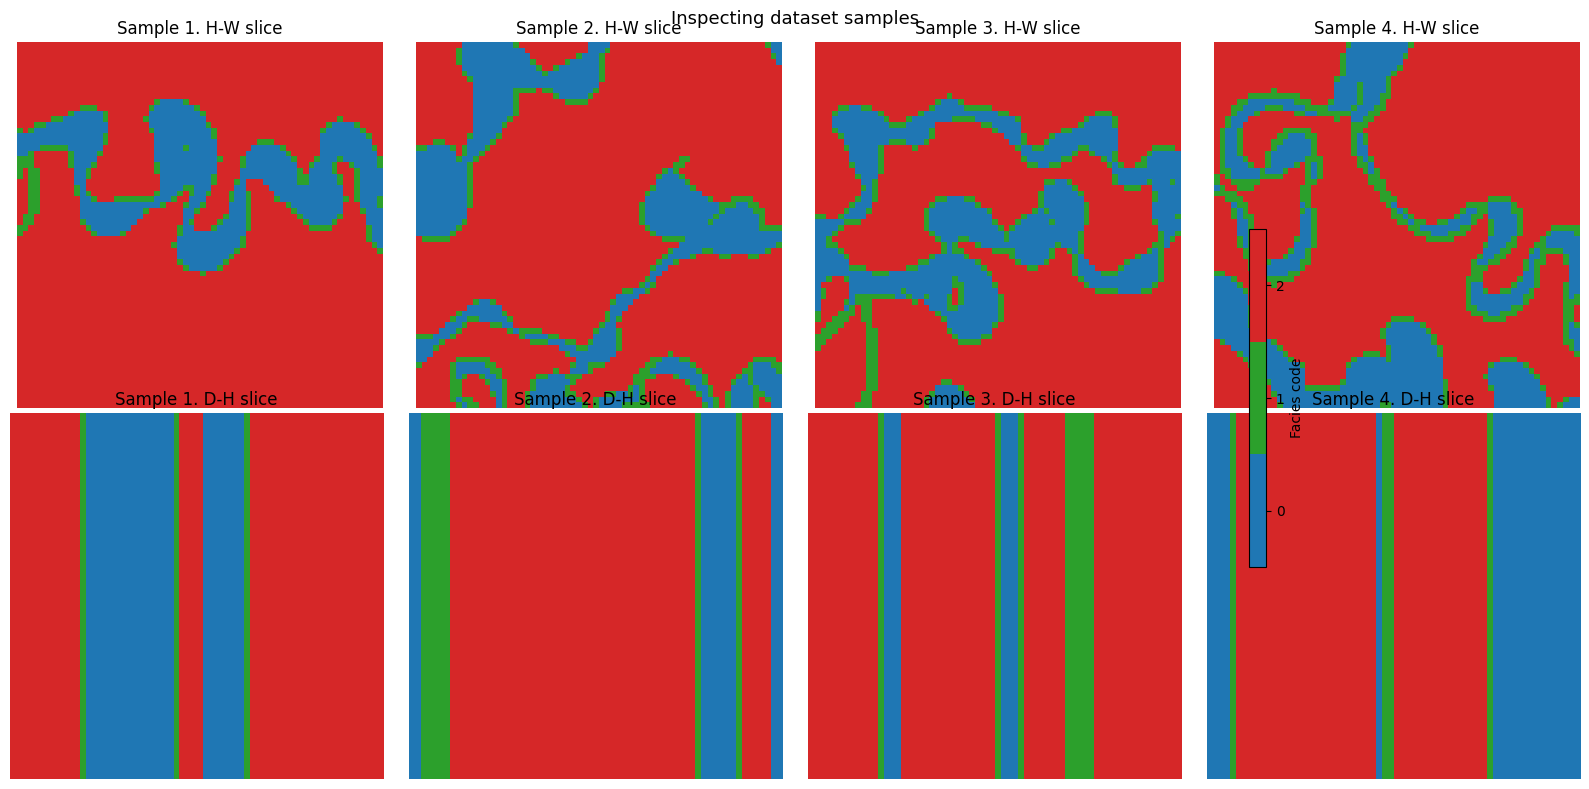

════════════════════════════════════════════════════════════════
  Pre-training forward-pass tests
════════════════════════════════════════════════════════════════

Forward-pass test — Scale 0  (64, 64, 2) …
  G output : torch.Size([2, 1, 2, 64, 64])
  D output : torch.Size([2, 1, 1, 8, 8])
VRAM  alloc=0.48 GB  reserved=0.52 GB  free≈15.12 GB  total=15.64 GB
  PASS ✓

Forward-pass test — Scale 1  (128, 128, 4) …
  G output : torch.Size([2, 1, 4, 128, 128])
  D output : torch.Size([2, 1, 1, 16, 16])
VRAM  alloc=1.00 GB  reserved=1.05 GB  free≈14.59 GB  total=15.64 GB
  PASS ✓

Forward-pass test — Scale 2  (256, 256, 8) …
  G output : torch.Size([2, 1, 8, 256, 256])
  D output : torch.Size([2, 1, 1, 16, 16])
VRAM  alloc=3.16 GB  reserved=3.27 GB  free≈12.37 GB  total=15.64 GB
  PASS ✓

Forward-pass test — Scale 3  (512, 512, 16) …
  G output : torch.Size([2, 1, 16, 512, 512])
  D output : torch.Size([2, 1, 1, 16, 16])
VRAM  alloc=11.79 GB  reserved=12.50 GB  free≈3.13 GB  total=15.64 GB


S0 Ep0001:  12%|██▌                  | 975/8000 [00:52<05:52, 19.94it/s, D=0.062, G=0.711]

In [ ]:
from matplotlib.colors import ListedColormap, Normalize

def denorm_to_codes(arr: np.ndarray, n_facies: int = None) -> np.ndarray:
    if n_facies is None:
        n_facies = cfg.N_FACIES
    hi = float(n_facies - 1)
    if hi < 1e-8:
        return np.zeros_like(arr)
    return np.round(((arr + 1) / 2) * hi).astype(np.int32)

def facies_cmap(n_facies: int):
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    if n_facies > len(colors):
        cmap = plt.cm.get_cmap('viridis', n_facies)
    else:
        cmap = ListedColormap(colors[:n_facies])
    norm = Normalize(vmin=-0.5, vmax=n_facies - 0.5)
    return cmap, norm

def inspect_dataset(n_show: int = 4):
    loader = GeoDataset.make_loader(scale_idx=0, batch_size=n_show)
    for real_batch in loader:
        real_samples = real_batch.cpu().numpy().squeeze(1) # (B, D, H, W)
        break

    D_dim = real_samples.shape[1]
    mid_d = D_dim // 2

    cmap, norm = facies_cmap(cfg.N_FACIES)

    fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
    if n_show == 1:
        axes = axes[:, np.newaxis]

    for i in range(n_show):
        vol = denorm_to_codes(real_samples[i]) # (D, H, W)
        im0 = axes[0, i].imshow(vol[mid_d], cmap=cmap, norm=norm,
                                interpolation="nearest")
        axes[0, i].set_title(f"Sample {i+1}. H-W slice")
        axes[0, i].axis("off")

        mid_w = vol.shape[2] // 2
        im1 = axes[1, i].imshow(vol[:, :, mid_w], cmap=cmap, norm=norm,
                                interpolation="nearest", aspect="auto")
        axes[1, i].set_title(f"Sample {i+1}. D-H slice")
        axes[1, i].axis("off")

    cbar = fig.colorbar(im0, ax=axes.ravel().tolist(),
                        ticks=range(cfg.N_FACIES), shrink=0.55)
    cbar.set_label("Facies code")
    plt.suptitle("Inspecting dataset samples", fontsize=13)
    plt.tight_layout()
    out = os.path.join(cfg.RESULTS_DIR, f"dataset_inspection.png")
    plt.savefig(out, dpi=90, bbox_inches="tight")
    plt.show()
    plt.close()


if __name__ == "__main__":

    # ── Step 0: Verify the data loaded correctly ──────────────────────────────
    # Displays real samples with the correct discrete facies colourmap.
    # Run this first — if the images look wrong, check cfg.N_FACIES and paths.
    print("Inspecting dataset …")
    inspect_dataset(n_show=4)

    # ── Step 1: Forward-pass sanity tests ─────────────────────────────────────
    # Catches OOM errors before wasting time.  Adjust cfg.BASE_CH or
    # cfg.BATCH_SIZE if a scale fails.
    print("═" * 64)
    print("  Pre-training forward-pass tests")
    print("═" * 64)
    for si in range(len(cfg.SCALES)):
        test_forward(si)

    # ── Step 2: Train (auto-resumes from latest checkpoint if one exists) ─────
    gan, trainers = train()

    # ── Step 3: Latent space interpolation ───────────────────────────────────
    # A smooth morphing between two realisations confirms the latent space is
    # well-structured — critical for the inverse problem solver downstream.
    print("\nLatent space interpolation …")
    interpolate_latent(gan, n_steps=10, scale_idx=1)   # scale 1 is fast

    # ── Step 4: Export for inverse problem ───────────────────────────────────
    # Saves facies_codes (int) + latent_vectors (float32) to a .npz file.
    # The inverse solver optimises z to match well observations, then calls
    # gan.generate(z) to get the corresponding subsurface model.
    save_for_inverse_problem(gan, n=100)

    print("\n  Done. All outputs written to:", cfg.RESULTS_DIR)
